# 03 - Python Exploratory Data Analysis

## AI-Assisted Hospital Operations & Patient Analytics Dashboard

This notebook starts **Stage 5: Python Exploratory Data Analysis (EDA)**.

The goal is to use Python, pandas, and matplotlib to explore the cleaned dataset and create visual insights before building the Power BI dashboard.

In this notebook, we will explore:

- admissions trends
- department workload
- disease patterns
- patient demographics
- length of stay
- billing and revenue
- payment status and payment mode
- insurance vs patient-payable amount


## 1. Import Libraries

We use common beginner-friendly Python libraries:

- `pandas` for data analysis
- `matplotlib` for charts
- `Path` for folder paths


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

plt.style.use("default")

## 2. Set Project Paths

We load processed files from `data/processed/` because Stage 3 already prepared cleaned analysis-ready data.

In [2]:
current_path = Path.cwd()

if (current_path / "data").exists():
    project_root = current_path
else:
    project_root = current_path.parent

processed_data_path = project_root / "data" / "processed"
visuals_path = project_root / "visuals"

visuals_path.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Processed data path:", processed_data_path)
print("Visuals path:", visuals_path)

Project root: C:\Users\devip\Desktop\Healthcare Projects\Healthcare-Analytics-Project
Processed data path: C:\Users\devip\Desktop\Healthcare Projects\Healthcare-Analytics-Project\data\processed
Visuals path: C:\Users\devip\Desktop\Healthcare Projects\Healthcare-Analytics-Project\visuals


## 3. Load Processed Tables

We load the main processed tables needed for EDA.

In [3]:
patient = pd.read_csv(processed_data_path / "processed_patient.csv")
admission = pd.read_csv(processed_data_path / "processed_admission.csv")
billing = pd.read_csv(processed_data_path / "processed_billing.csv")
department = pd.read_csv(processed_data_path / "processed_department.csv")
disease = pd.read_csv(processed_data_path / "processed_disease.csv")
patient_diagnostic = pd.read_csv(processed_data_path / "processed_patient_diagnostic.csv")
diagnostic_test = pd.read_csv(processed_data_path / "processed_diagnostic_test.csv")
prescription = pd.read_csv(processed_data_path / "processed_prescription.csv")
drug = pd.read_csv(processed_data_path / "processed_drug.csv")
bed = pd.read_csv(processed_data_path / "processed_bed.csv")
ward = pd.read_csv(processed_data_path / "processed_ward.csv")

print("Tables loaded successfully")

Tables loaded successfully


## 4. Convert Date Columns

CSV files do not preserve datetime data types, so we convert date columns again after loading.

In [4]:
patient["date_of_birth"] = pd.to_datetime(patient["date_of_birth"])
admission["admission_date"] = pd.to_datetime(admission["admission_date"])
admission["discharge_date"] = pd.to_datetime(admission["discharge_date"])
billing["bill_date"] = pd.to_datetime(billing["bill_date"])
patient_diagnostic["test_date"] = pd.to_datetime(patient_diagnostic["test_date"])

print("Date columns converted successfully")

Date columns converted successfully


## 5. Create Analysis Tables

To make EDA easier, we create joined tables for admissions, clinical analysis, and financial analysis.

Important: We use `billing` as the financial source of truth based on Stage 3 validation.

In [5]:
admission_analysis = (
    admission
    .merge(patient[["patient_id", "gender", "patient_age", "age_group", "city"]], on="patient_id", how="left")
    .merge(department[["department_id", "department_name", "department_type"]], on="department_id", how="left")
    .merge(disease[["disease_id", "disease_name", "disease_category"]], on="disease_id", how="left")
)

financial_analysis = (
    admission_analysis
    .merge(billing[[
        "admission_id", "bill_id", "total_amount", "insurance_covered_amount",
        "patient_payable_amount", "payment_status", "payment_mode",
        "insurance_coverage_percent"
    ]], on="admission_id", how="left")
)

print("Admission analysis shape:", admission_analysis.shape)
print("Financial analysis shape:", financial_analysis.shape)

Admission analysis shape: (45000, 23)
Financial analysis shape: (45000, 30)


## 6. Core Dataset Snapshot

These are the headline numbers for the dataset.

In [6]:
core_snapshot = pd.DataFrame([{
    "total_registered_patients": patient["patient_id"].nunique(),
    "total_admissions": admission["admission_id"].nunique(),
    "admitted_patients": admission["patient_id"].nunique(),
    "total_revenue": billing["total_amount"].sum(),
    "average_length_of_stay": round(admission["length_of_stay_days"].mean(), 2),
    "total_diagnostic_tests": len(patient_diagnostic),
    "total_prescriptions": len(prescription),
}])

core_snapshot

,total_registered_patients,total_admissions,admitted_patients,total_revenue,average_length_of_stay,total_diagnostic_tests,total_prescriptions
0,30000,45000,23275,1684246109,5.16,63269,73109


## 7. Admissions Trend by Year

This chart shows whether hospital admission volume changed over time.

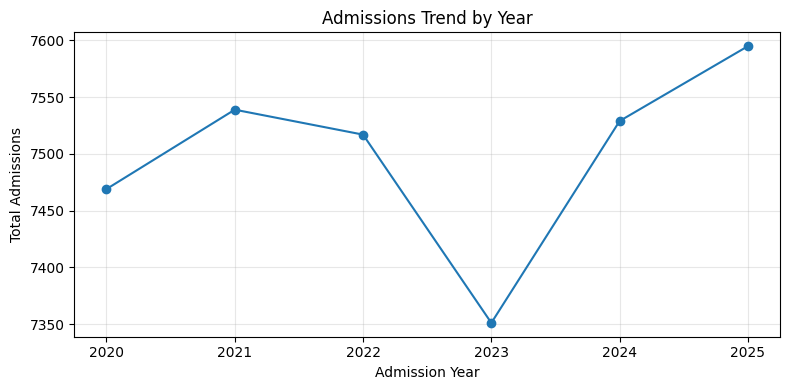

,admission_year,total_admissions
0,2020,7469
1,2021,7539
2,2022,7517
3,2023,7351
4,2024,7529
5,2025,7595


In [7]:
admissions_by_year = (
    admission
    .groupby("admission_year")
    .agg(total_admissions=("admission_id", "count"))
    .reset_index()
)

plt.figure(figsize=(8, 4))
plt.plot(admissions_by_year["admission_year"], admissions_by_year["total_admissions"], marker="o")
plt.title("Admissions Trend by Year")
plt.xlabel("Admission Year")
plt.ylabel("Total Admissions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(visuals_path / "admissions_trend_by_year.png", dpi=150)
plt.show()

admissions_by_year

## 8. Department Workload

This chart shows which hospital departments handled the highest number of admissions.

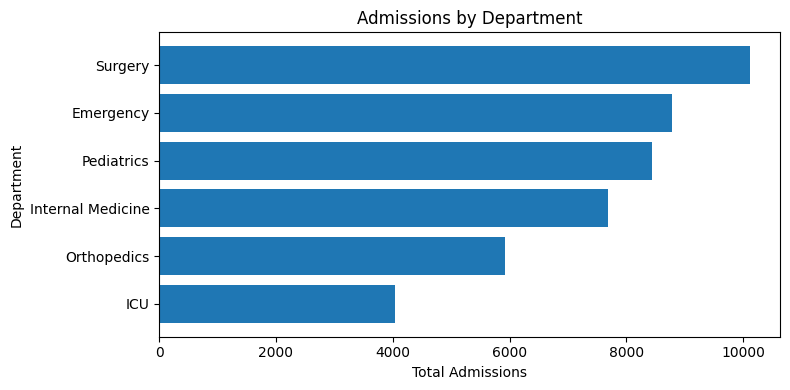

,department_name,total_admissions
5,Surgery,10126
0,Emergency,8777
4,Pediatrics,8438
2,Internal Medicine,7695
3,Orthopedics,5924
1,ICU,4040


In [8]:
department_workload = (
    admission_analysis
    .groupby("department_name")
    .agg(total_admissions=("admission_id", "count"))
    .reset_index()
    .sort_values("total_admissions", ascending=True)
)

plt.figure(figsize=(8, 4))
plt.barh(department_workload["department_name"], department_workload["total_admissions"])
plt.title("Admissions by Department")
plt.xlabel("Total Admissions")
plt.ylabel("Department")
plt.tight_layout()
plt.savefig(visuals_path / "admissions_by_department.png", dpi=150)
plt.show()

department_workload.sort_values("total_admissions", ascending=False)

## 9. Average Length of Stay by Department

Length of stay is a key hospital operations metric. Longer stays may affect bed availability and resource planning.

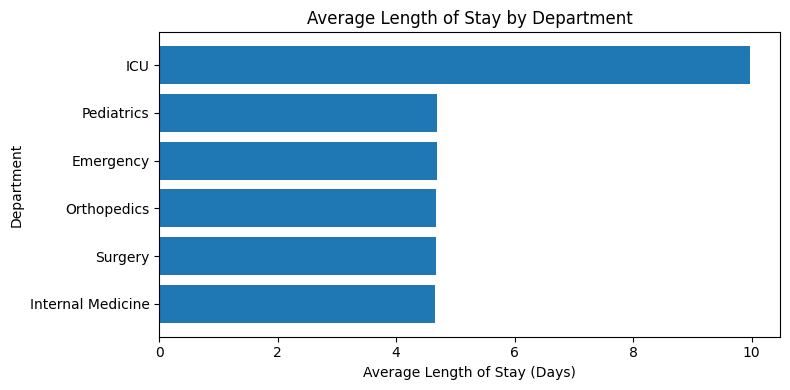

,department_name,average_length_of_stay
1,ICU,9.98
0,Emergency,4.69
4,Pediatrics,4.69
3,Orthopedics,4.68
5,Surgery,4.67
2,Internal Medicine,4.66


In [9]:
los_by_department = (
    admission_analysis
    .groupby("department_name")
    .agg(average_length_of_stay=("length_of_stay_days", "mean"))
    .reset_index()
)

los_by_department["average_length_of_stay"] = los_by_department["average_length_of_stay"].round(2)
los_by_department = los_by_department.sort_values("average_length_of_stay", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(los_by_department["department_name"], los_by_department["average_length_of_stay"])
plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Department")
plt.tight_layout()
plt.savefig(visuals_path / "average_los_by_department.png", dpi=150)
plt.show()

los_by_department.sort_values("average_length_of_stay", ascending=False)

## 10. Disease Category Distribution

This chart shows the most common disease categories in admissions.

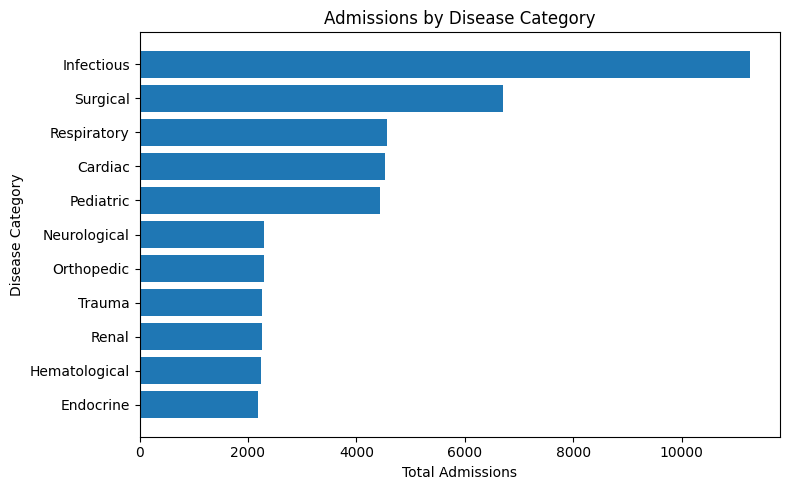

,disease_category,total_admissions
3,Infectious,11248
9,Surgical,6711
8,Respiratory,4564
0,Cardiac,4525
6,Pediatric,4436
4,Neurological,2300
5,Orthopedic,2288
10,Trauma,2253
7,Renal,2251
2,Hematological,2235


In [10]:
disease_category_counts = (
    admission_analysis
    .groupby("disease_category")
    .agg(total_admissions=("admission_id", "count"))
    .reset_index()
    .sort_values("total_admissions", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(disease_category_counts["disease_category"], disease_category_counts["total_admissions"])
plt.title("Admissions by Disease Category")
plt.xlabel("Total Admissions")
plt.ylabel("Disease Category")
plt.tight_layout()
plt.savefig(visuals_path / "admissions_by_disease_category.png", dpi=150)
plt.show()

disease_category_counts.sort_values("total_admissions", ascending=False)

## 11. Patient Age Group Distribution

This helps understand the patient population served by the hospital.

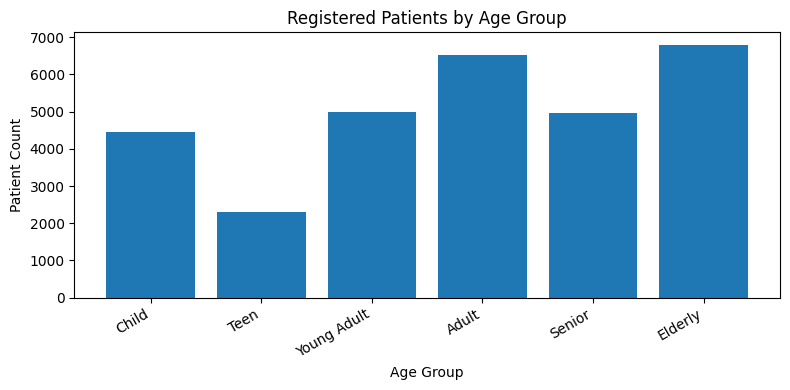

,age_group,patient_count
0,Child,4443
1,Teen,2314
2,Young Adult,4980
3,Adult,6513
4,Senior,4957
5,Elderly,6793


In [11]:
age_group_order = ["Child", "Teen", "Young Adult", "Adult", "Senior", "Elderly"]

age_group_counts = (
    patient["age_group"]
    .value_counts()
    .reindex(age_group_order)
    .reset_index()
)

age_group_counts.columns = ["age_group", "patient_count"]

plt.figure(figsize=(8, 4))
plt.bar(age_group_counts["age_group"], age_group_counts["patient_count"])
plt.title("Registered Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(visuals_path / "patients_by_age_group.png", dpi=150)
plt.show()

age_group_counts

## 12. Revenue by Department

This chart shows financial contribution by department.

Reminder: `billing` is the financial source of truth.

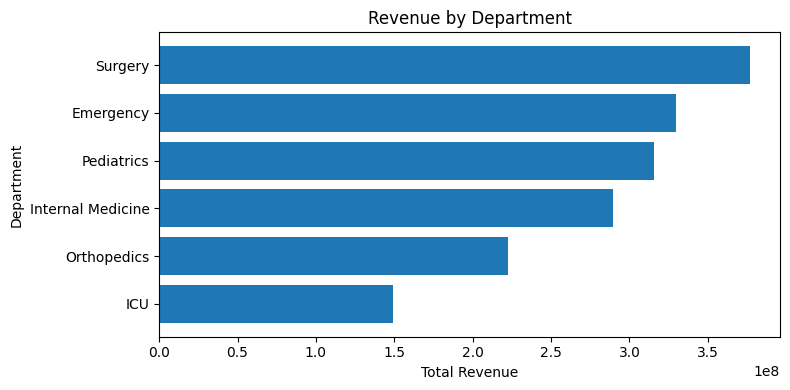

,department_name,total_revenue
5,Surgery,377216234
0,Emergency,329738229
4,Pediatrics,315714822
2,Internal Medicine,289566059
3,Orthopedics,222585716
1,ICU,149425049


In [12]:
revenue_by_department = (
    financial_analysis
    .groupby("department_name")
    .agg(total_revenue=("total_amount", "sum"))
    .reset_index()
    .sort_values("total_revenue", ascending=True)
)

plt.figure(figsize=(8, 4))
plt.barh(revenue_by_department["department_name"], revenue_by_department["total_revenue"])
plt.title("Revenue by Department")
plt.xlabel("Total Revenue")
plt.ylabel("Department")
plt.tight_layout()
plt.savefig(visuals_path / "revenue_by_department.png", dpi=150)
plt.show()

revenue_by_department.sort_values("total_revenue", ascending=False)

## 13. Insurance vs Patient Payable Amount

This chart compares the financial contribution from insurance and patients.

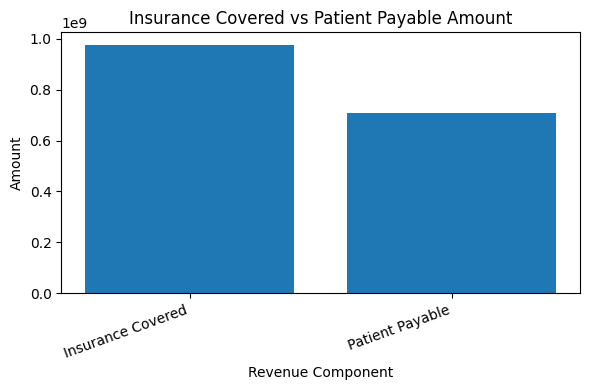

,component,amount
0,Insurance Covered,976880867.0
1,Patient Payable,707365242.0


In [13]:
revenue_split = pd.DataFrame({
    "component": ["Insurance Covered", "Patient Payable"],
    "amount": [billing["insurance_covered_amount"].sum(), billing["patient_payable_amount"].sum()]
})

plt.figure(figsize=(6, 4))
plt.bar(revenue_split["component"], revenue_split["amount"])
plt.title("Insurance Covered vs Patient Payable Amount")
plt.xlabel("Revenue Component")
plt.ylabel("Amount")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(visuals_path / "insurance_vs_patient_payable.png", dpi=150)
plt.show()

revenue_split

## 14. Payment Status Distribution

This chart shows paid vs pending bills.

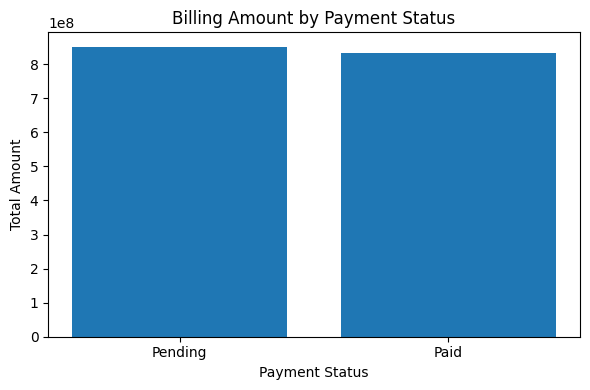

,payment_status,total_amount,total_bills
1,Pending,851212656,22670
0,Paid,833033453,22330


In [14]:
payment_status_summary = (
    billing
    .groupby("payment_status")
    .agg(total_amount=("total_amount", "sum"), total_bills=("bill_id", "count"))
    .reset_index()
    .sort_values("total_amount", ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(payment_status_summary["payment_status"], payment_status_summary["total_amount"])
plt.title("Billing Amount by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.savefig(visuals_path / "billing_amount_by_payment_status.png", dpi=150)
plt.show()

payment_status_summary

## 15. Diagnostic Result Status

This shows the split between normal and abnormal diagnostic results.

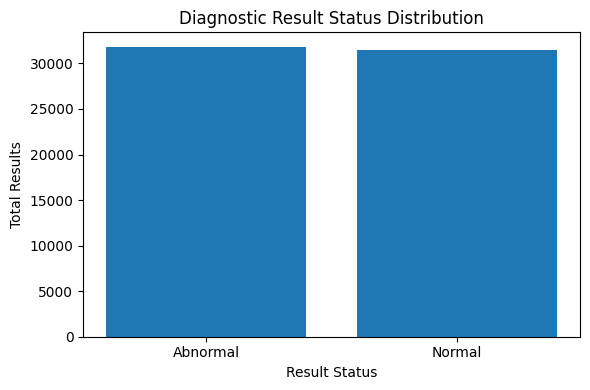

,result_status,total_results
0,Abnormal,31823
1,Normal,31446


In [15]:
diagnostic_result_summary = (
    patient_diagnostic
    .groupby("result_status")
    .agg(total_results=("patient_diagnostic_id", "count"))
    .reset_index()
    .sort_values("total_results", ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(diagnostic_result_summary["result_status"], diagnostic_result_summary["total_results"])
plt.title("Diagnostic Result Status Distribution")
plt.xlabel("Result Status")
plt.ylabel("Total Results")
plt.tight_layout()
plt.savefig(visuals_path / "diagnostic_result_status.png", dpi=150)
plt.show()

diagnostic_result_summary

## 16. EDA Findings Summary

After running the notebook, use this section to write the most important findings.

Suggested findings to check:

- Are admissions stable across years?
- Which department has the highest workload?
- Which department has the longest length of stay?
- Which disease category is most common?
- Which age group is largest?
- Which department generates the highest revenue?
- Is insurance-covered amount higher than patient-payable amount?
- Are pending bills financially important?
